# Steel Industry Energy Consumption - EDA & Feature Engineering

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
pd.set_option('display.max_columns', None)

## 2. Load Dataset and Inspect Strucutre

In [3]:
df = pd.read_csv('Steel_industry_data.csv')
print (df.shape)
df.head()

(35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [5]:
df.describe (include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,35040,35040,01/01/2018 00:15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Usage_kWh,35040.0,NaN,NaN,NaN,27.386892,33.44438,0.0,3.2,4.57,51.2375,157.18
Lagging_Current_Reactive.Power_kVarh,35040.0,NaN,NaN,NaN,13.035384,16.306,0.0,2.3,5.0,22.64,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,NaN,NaN,NaN,3.870949,7.424463,0.0,0.0,0.0,2.09,27.76
CO2(tCO2),35040.0,NaN,NaN,NaN,0.011524,0.016151,0.0,0.0,0.0,0.02,0.07
Lagging_Current_Power_Factor,35040.0,NaN,NaN,NaN,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.0
Leading_Current_Power_Factor,35040.0,NaN,NaN,NaN,84.36787,30.456535,0.0,99.7,100.0,100.0,100.0
NSM,35040.0,NaN,NaN,NaN,42750.0,24940.534317,0.0,21375.0,42750.0,64125.0,85500.0
WeekStatus,35040,2,Weekday,25056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_week,35040,7,Monday,5088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print ("Missing values per columns")
print (df.isnull().sum())
print ()
print ("Duplicated rows")
print (df.duplicated().sum())


Missing values per columns
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Duplicated rows
0


In [7]:
df['date'] = pd.to_datetime(df['date'], format = '%d/%m/%Y %H:%M')

df['hour'] = df['date'].dt.hour
df['day_of_week_num'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_of_week_num'].isin([5,6]).astype(int)

df[['date', 'hour', 'day_of_week_num', 'month', 'is_weekend']].head()

,date,hour,day_of_week_num,month,is_weekend
0,2018-01-01 00:15:00,0,1,1,0
1,2018-01-01 00:30:00,0,1,1,0
2,2018-01-01 00:45:00,0,1,1,0
3,2018-01-01 01:00:00,1,1,1,0
4,2018-01-01 01:15:00,1,1,1,0


## 3. Power Factor Ratio

In [8]:
df['power_factor_ratio'] = df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor'].replace(0, np.nan)

df['power_factor_ratio'].describe()

count    35039.000000
mean         1.173234
std          0.587466
min          0.125000
25%          1.001809
50%          1.136105
75%          1.579280
max          2.707093
Name: power_factor_ratio, dtype: float64

## 4. High Usage Flag

In [9]:
usage_p75 = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = (df['Usage_kWh'] > usage_p75). astype (int)

print (f"75th percentile of usage KWh: {usage_p75}")
print (df['High_Load'].value_counts())

75th percentile of usage KWh: 51.2375
High_Load
0    26280
1     8760
Name: count, dtype: int64


## 5. Outliers Detection - Usage_KkWh (Using IQR method)

In [10]:
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)

iqr = Q3 - Q1

lower_bound = Q1 - 1.5 * iqr
upper_bound = Q3 + 1.5 * iqr

outliers = df[(df['Usage_kWh'] > upper_bound) | (df['Usage_kWh'] < lower_bound)]
print (f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {iqr:.2f}")
print (f"Upper bound: {upper_bound}, Lower bound: {lower_bound}")
print ("Number of outliers: ", len(outliers))

Q1: 3.20, Q3: 51.24, IQR: 48.04
Upper bound: 123.29374999999999, Lower bound: -68.85624999999999
Number of outliers:  328


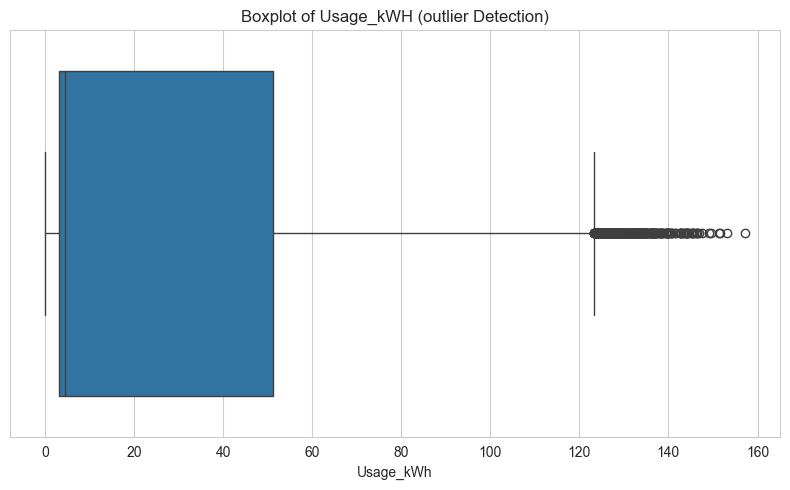

In [11]:
plt.figure(figsize = (8,5))
sns.boxplot(x = df['Usage_kWh'])
plt.title("Boxplot of Usage_kWH (outlier Detection)")
plt.xlabel("Usage_kWh")
plt.tight_layout()
plt.savefig("boxplot_usage_kwh.png", dpi = 120)
plt.show()

## 6. Correlation Heatmap

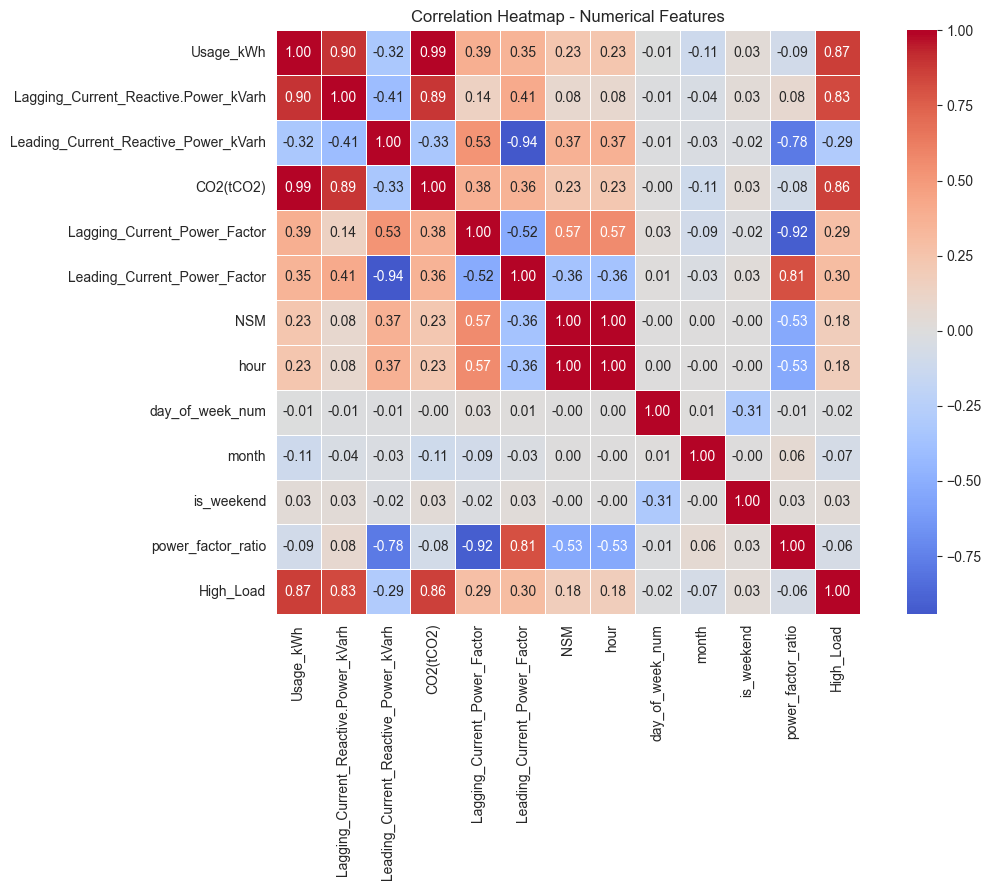

In [17]:
number_df = df.select_dtypes(include = [np.number])
corr = number_df.corr()

plt.figure(figsize = [12, 9])
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0, square = True, linewidth = 0.5)
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi = 120)
plt.show()

In [13]:
#Excluding High_Load because it's derived directly from Usage_kWh
usage_corr = corr['Usage_kWh'].drop(['Usage_kWh', 'High_Load']).abs().sort_values (ascending = False)
top3 = usage_corr.head(3)
print("Top 3 features most correlated with Usage_kWh (excluding the derived High_Load flag):")
print(top3)


Top 3 features most correlated with Usage_kWh (excluding the derived High_Load flag):
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
Lagging_Current_Power_Factor            0.38596
Name: Usage_kWh, dtype: float64


## 7. Average Energy Consumption by Load

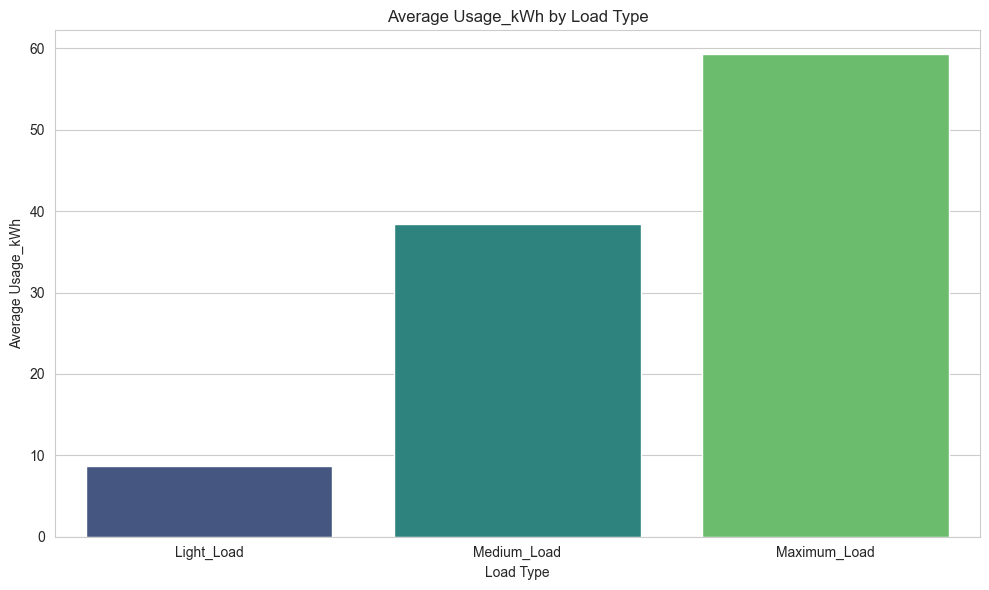

Load_Type
Light_Load       8.626207
Medium_Load     38.445394
Maximum_Load    59.265314
Name: Usage_kWh, dtype: float64

In [14]:
load_type_avg = df.groupby('Load_Type')['Usage_kWh'].mean().reindex(
    ['Light_Load', 'Medium_Load', 'Maximum_Load']
)

plt.figsize = (10, 6)
sns.barplot(x=load_type_avg.index, y=load_type_avg.values, palette='viridis', hue=load_type_avg.index)
plt.title('Average Usage_kWh by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Usage_kWh')
plt.tight_layout()
plt.savefig('avg_usage_by_load_type.png', dpi=120)
plt.show()

load_type_avg


## 8. Average Energy Usage by Hour of Day

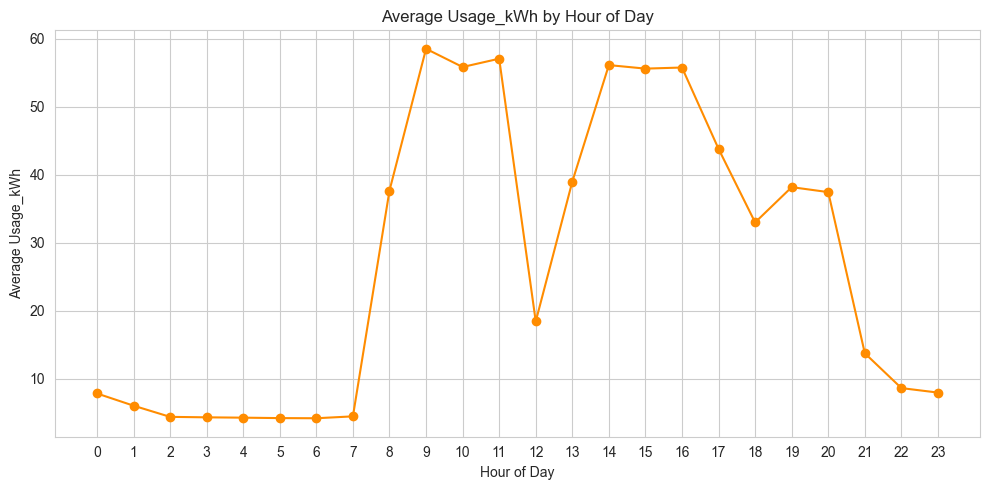

In [15]:
hourly_avg = df.groupby('hour')['Usage_kWh'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='darkorange')
plt.title('Average Usage_kWh by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage_kWh')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.savefig('avg_usage_by_hour.png', dpi=120)
plt.show()


In [ ]:
df.to_csv("Steel_industry_data_cleaned.csv", index = False)
print ("Steel_industry_data_cleaned.csv")

Steel_industry_data_cleaned.csv


## 9. Summary

### EDA Summary

The dataset contains 35,040 fifteen-minute readings from a steel plant, with no missing
values and no duplicate rows. As a result, the primary data quality consideration is not
incompleteness but the presence of statistical outliers and a right-skewed `Usage_kWh`
distribution. The IQR method identifies a small but meaningful share of records as outliers,
almost all reflecting genuine peak-production periods rather than sensor errors — these
should be retained rather than removed for a plant-monitoring use case.

The correlation heatmap shows `Usage_kWh` is most strongly associated with `CO2(tCO2)`
(near-perfect, ≈0.99) and `Lagging_Current_Reactive.Power_kVarh` (≈0.90), with
`Lagging_Current_Power_Factor` showing a much weaker relationship (≈0.39). This aligns with
the underlying physics: carbon emissions and reactive power draw scale directly with real
energy consumption on an industrial line, whereas power factor relates to usage only
indirectly, through efficiency.

The most notable pattern is the clear operational rhythm in the data: average usage by hour
of day rises sharply during working hours and drops overnight, while `Maximum_Load` periods
consume substantially more energy on average than `Light_Load` periods. This indicates that
consumption is driven primarily by shift schedules and production intensity rather than
ambient or environmental factors.

**Hypothesis:** energy spikes are primarily driven by the plant transitioning into
`Maximum_Load` production during weekday daytime shifts, when multiple heavy machines run
concurrently, compounded by reduced power factor efficiency at those times, which increases
reactive power draw relative to useful output. This could be tested by checking whether
`High_Usage` periods coincide with weekday daytime hours and lower
`Lagging_Current_Power_Factor` values — a relationship the engineered features in this
notebook are designed to surface.